# **Microproyecto 2 - Modelado de topicos ODS**

## **Maestria en Inteligencia Artificial - Universidad de los Andes** Machine Learning No Supervisado

Integrantes:
- Carlos Alberto Ortiz Grillo
- Juan Sebastian Cervantes Restrepo


Actividades para realizar:

1. Preparación de los textos utilizando el esquema de bolsa de palabras (BOW)l con una pesado TF-IDF. Para este paso construir un pipeline que integre las transformaciones que se consideren adecuadas.

2. A partir de la matriz TF-IDF construida en el paso anterior, aplica el algoritmo SVD truncado (TruncatedSVD de scikit-learn) para obtener un modelo de tópicos mediante análisis semántico latente (LSA). Explora un número reducido de componentes (por ejemplo, entre 10 y 20) y, para al menos 5 de ellas, identifica y muestra las palabras con mayor peso (loadings), a modo de "tópicos". Interpreta cualitativamente si estos tópicos guardan relación con algunos de los 17 ODS trabajados en el proyecto.

3. Desarrollo de un modelo de clasificación que permita relacionar un texto con un ODS. Para manejar la complejidad del espacio de entrada, puedes reutilizar la misma descomposición SVD obtenida en la actividad anterior (LSA), o aplicar otro algoritmo de reducción de la dimensionalidad que consideres pertinente

4. Evaluación del modelo de clasificación con textos que no hayan sido utilizados para el aprendizaje.

In [15]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import os
import re

In [5]:
os.getcwd()
os.chdir(r"D:\MAIA\ML no Supervisado\Proyectos\Tipicos_ODS")

In [8]:
raw_data = pd.read_excel(r"Data\Datos_textosODS.xlsx")
# Validamos la el cargue de los datos
print(raw_data.shape)

(9656, 2)


In [9]:
raw_data.head()

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


## EDA Textual

In [11]:
# Antes de realizar la preparacion del texto vamos a validar la calidad
data = raw_data.copy()

### Conteo y porcentaje de textos por ODS

In [13]:
# Conteo y porcentaje de textos por ODS, para dimensionar el desbalance de clases
ods_dist = data["ODS"].value_counts().sort_index()
ods_pct = (ods_dist / ods_dist.sum() * 100).round(2)

resumen_ods = pd.DataFrame({"conteo": ods_dist, "porcentaje": ods_pct})
resumen_ods.sort_values("conteo", ascending=False)

,conteo,porcentaje
ODS,,
16,1080,11.18
5,1070,11.08
4,1025,10.62
3,894,9.26
7,787,8.15
6,695,7.20
11,607,6.29
1,505,5.23
13,464,4.81


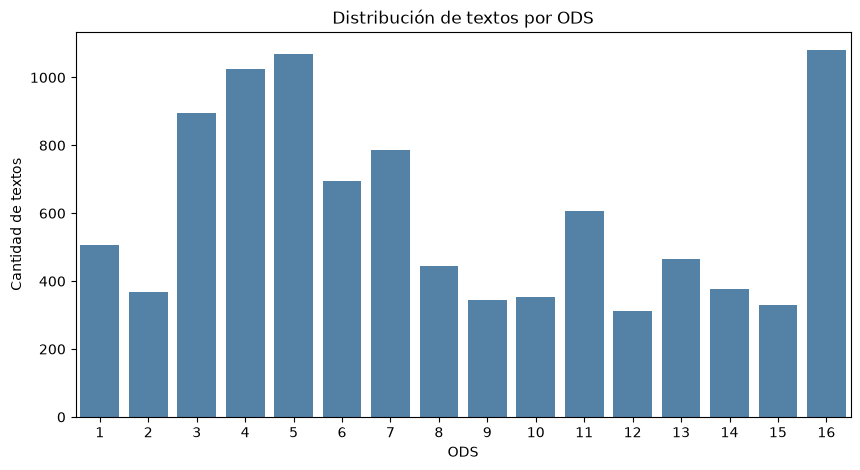

In [16]:
# Grafico de barras de la distribucion de textos por ODS
orden = ods_dist.sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
sn.barplot(x=orden, y=ods_dist.loc[orden].values, color="steelblue")
plt.title("Distribución de textos por ODS")
plt.xlabel("ODS")
plt.ylabel("Cantidad de textos")
plt.show()

**Observaciones sobre la variable objetivo (ODS):**

- El dataset cubre 16 de los 17 ODS (no hay textos etiquetados con el ODS 17 - *Alianzas para lograr los objetivos*).
- Hay desbalance de clases: el ODS 16 (*Paz, justicia e instituciones sólidas*, 1080 textos, 11.2%) y el ODS 5 (*Igualdad de género*, 1070 textos, 11.1%) son los más representados, mientras que el ODS 12 (*Producción y consumo responsables*, 312 textos, 3.2%) es el menos representado. La razón entre la clase mayoritaria y la minoritaria es de ~3.5x, un desbalance moderado (no extremo).
- Implicaciones para las siguientes etapas del proyecto:
  - Al separar train/test, usar `stratify=data["ODS"]` para conservar las proporciones de cada clase en ambos conjuntos.
  - Al evaluar el modelo de clasificación, no basarse solo en accuracy (se puede inflar por las clases mayoritarias); usar F1 macro y/o matriz de confusión por ODS.

### Conteo de palabras por texto

In [ ]:
# Conteo de palabras por texto
data["conteo_palabras"] = data["textos"].apply(lambda x: len(str(x).split()))

In [20]:
# Estadisticas descriptivas de la longitud de los textos (en palabras)
data["conteo_palabras"].describe()

count    9656.000000
mean      111.017295
std        37.082212
min        24.000000
25%        82.000000
50%       105.000000
75%       135.000000
max       268.000000
Name: conteo_palabras, dtype: float64

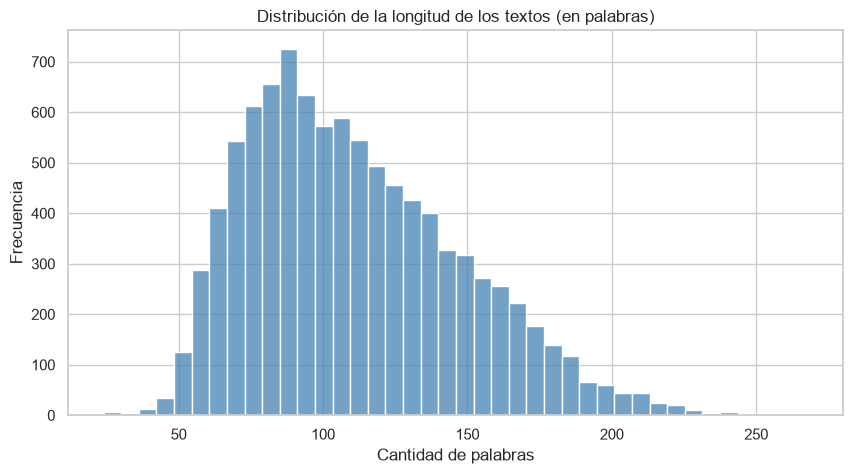

In [21]:
# Histograma de la longitud de los textos
plt.figure(figsize=(10, 5))
sn.histplot(data["conteo_palabras"], bins=40, color="steelblue")
plt.title("Distribución de la longitud de los textos (en palabras)")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Frecuencia")
plt.show()

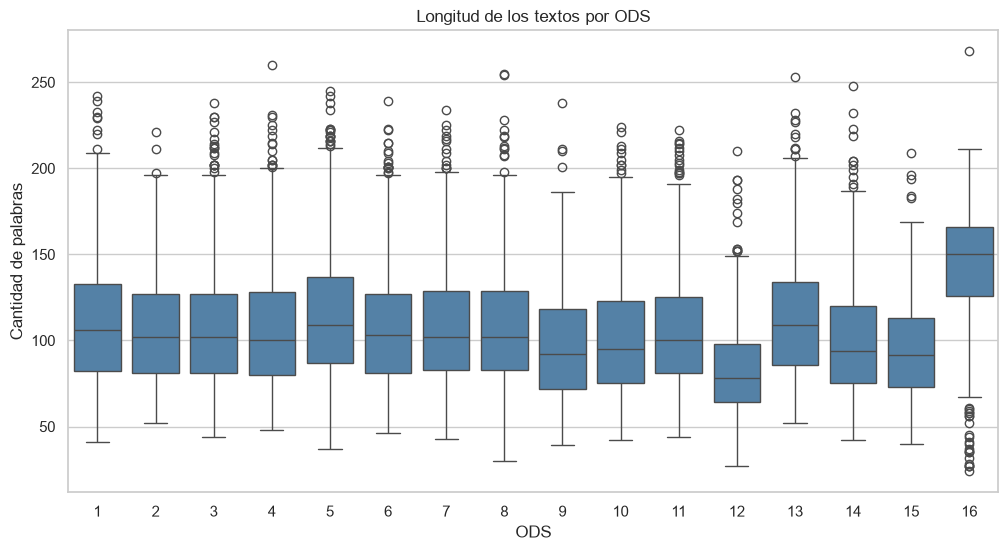

In [22]:
# Longitud de los textos por ODS, para ver si algun objetivo tiene textos sistematicamente mas largos/cortos
plt.figure(figsize=(12, 6))
sn.boxplot(x="ODS", y="conteo_palabras", data=data, color="steelblue")
plt.title("Longitud de los textos por ODS")
plt.xlabel("ODS")
plt.ylabel("Cantidad de palabras")
plt.show()

### Revision de ruido

In [24]:
# Presencia de URLs y etiquetas HTML en los textos
# Si tiene URL o HTML
data["has_url"] = data["textos"].apply(
    lambda x: bool(re.search(r"http[s]?://", str(x)))
)
data["has_html"] = data["textos"].apply(
    lambda x: bool(re.search(r"<[^>]+>", str(x)))
)
print("Textos con URL:", data["has_url"].sum())
print("Textos con HTML:", data["has_html"].sum())
data.loc[data["has_url"], "textos"].head(3)

Textos con URL: 42
Textos con HTML: 1


309    Los documentos pueden telecargarse a partir de...
475    Disponible en: http://www.ilo.org/sapfl/lnform...
535    Si bien la tendencia en el cuidado de las adic...
Name: textos, dtype: str

**Observaciones sobre la longitud de los textos y el ruido:**

- La longitud oscila entre 24 y 268 palabras, con media 111 y mediana 105 — son fragmentos/párrafos, no documentos completos, y no hay textos extremadamente cortos (sin contenido) ni extremadamente largos que deban filtrarse.
- Por ODS, la mayoría se mueve en un rango similar (~85 a ~115 palabras en promedio), salvo el ODS 16 (*Paz, justicia e instituciones sólidas*), que es notablemente más largo (media 143.8, mediana 150) — coherente con textos de tipo normativo/institucional, que tienden a ser más extensos. El ODS 12 (*Producción y consumo responsables*) es el más corto en promedio (84.9).
- Se encontraron 42 textos con URLs y 1 con una etiqueta HTML — poco frecuente sobre 9656 textos, pero no despreciable. **Decisión para el pipeline de limpieza:** eliminar URLs y etiquetas HTML con expresiones regulares antes de vectorizar, ya que no aportan información semántica y podrían inflar el vocabulario del TF-IDF con tokens ruidosos (partes de URLs, tags).

### Vocabulario global

Tokenizamos todos los textos (minúsculas, solo letras) y contamos frecuencias para dimensionar el vocabulario y ver qué palabras dominan antes de aplicar cualquier limpieza.

In [25]:
from collections import Counter

# Tokenizacion simple: minusculas y solo letras (incluye tildes y ñ)
def tokenizar(texto):
    texto = str(texto).lower()
    return re.findall(r"[a-záéíóúñü]+", texto)


todos_los_tokens = []
for t in data["textos"]:
    todos_los_tokens.extend(tokenizar(t))

print("Total de tokens:", len(todos_los_tokens))
print("Vocabulario (tokens unicos):", len(set(todos_los_tokens)))

Total de tokens: 1054088
Vocabulario (tokens unicos): 33519


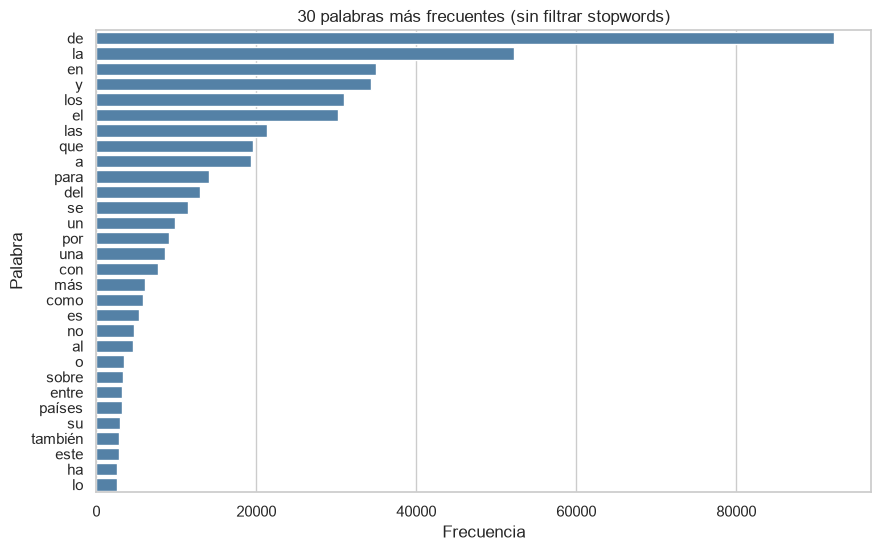

In [26]:
# 30 palabras mas frecuentes, sin ningun filtro todavia
frecuencia_global = Counter(todos_los_tokens)
top_30_bruto = frecuencia_global.most_common(30)

plt.figure(figsize=(10, 6))
palabras, frecuencias = zip(*top_30_bruto)
sn.barplot(x=list(frecuencias), y=list(palabras), color="steelblue")
plt.title("30 palabras más frecuentes (sin filtrar stopwords)")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.show()

Como era de esperar, las 30 palabras más frecuentes son casi todas **stopwords** del español ("de", "la", "en", "y", "los", "el"...) sin contenido semántico propio. Filtramos con la lista de stopwords de NLTK para ver qué queda del vocabulario realmente informativo.

Vocabulario sin stopwords: 33026


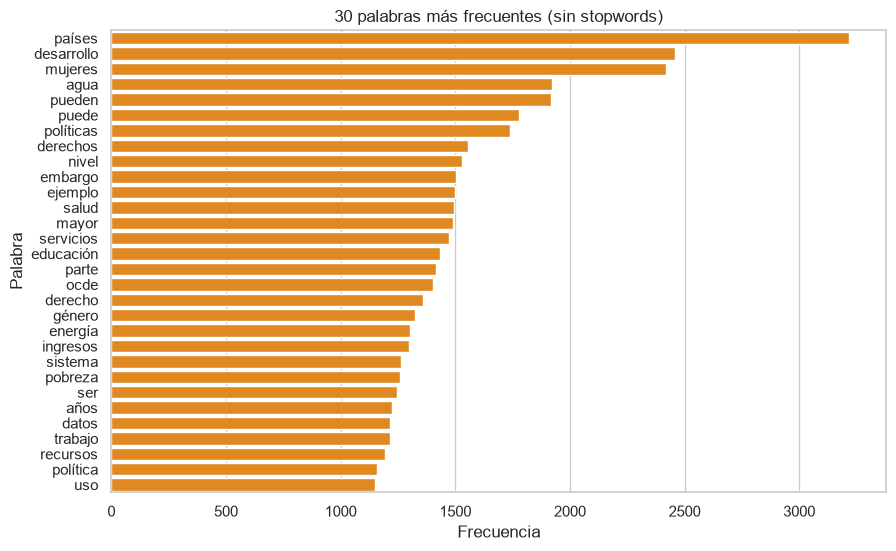

In [27]:
import nltk

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

stopwords_es = set(stopwords.words("spanish"))

# Filtramos stopwords y palabras muy cortas (1-2 letras, poco informativas)
tokens_filtrados = [
    w for w in todos_los_tokens if w not in stopwords_es and len(w) > 2
]
frecuencia_filtrada = Counter(tokens_filtrados)

print("Vocabulario sin stopwords:", len(frecuencia_filtrada))
top_30_filtrado = frecuencia_filtrada.most_common(30)

plt.figure(figsize=(10, 6))
palabras_f, frecuencias_f = zip(*top_30_filtrado)
sn.barplot(x=list(frecuencias_f), y=list(palabras_f), color="darkorange")
plt.title("30 palabras más frecuentes (sin stopwords)")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.show()

**Observaciones sobre el vocabulario global:**

- El corpus tiene ~1.05 millones de tokens y un vocabulario de **33,519 palabras únicas** (sin filtrar), que baja apenas a ~33,000 al quitar stopwords — es decir, casi todo el vocabulario es de contenido, y lo que domina en frecuencia bruta son solo un puñado de stopwords repetidas muchísimas veces.
- Al remover stopwords, las palabras más frecuentes ya son temáticamente relevantes y se alinean con varios ODS: "desarrollo", "mujeres", "agua", "políticas", "derechos", "salud", "educación", "género", "energía", "pobreza". Esto confirma que el texto sí tiene señal suficiente para diferenciar ODS.
- También aparecen palabras funcionales que NLTK no considera stopwords pero aportan poco valor discriminativo ("pueden", "puede", "embargo", "ejemplo", "mayor", "parte", "ser") y una entidad recurrente ("ocde"). No es necesario tratarlas ahora; el propio TF-IDF les va a asignar peso bajo por ser muy comunes en casi todos los ODS.

**Decisiones para el pipeline de la actividad 1 (TF-IDF):**
- Usar `stop_words` con la lista de NLTK en español dentro del `TfidfVectorizer` (o pasarla en el pipeline de limpieza previo).
- `lowercase=True` y un `token_pattern` que conserve tildes y "ñ" (por defecto de sklearn ya captura letras acentuadas si se usa `\w+`, pero conviene validarlo).
- Fijar `min_df` (p. ej. 2-3) para descartar palabras rarísimas (posibles errores tipográficos o ruido) y `max_df` (p. ej. 0.9) para atenuar palabras casi universales que no discriminan entre ODS.

### N-gramas

Revisamos bigramas y trigramas más frecuentes (sin stopwords) para detectar conceptos de varias palabras que un análisis de unigramas por sí solo perdería (p. ej. "derechos humanos" o "cambio climático" no significan lo mismo separadas). Esto ayuda a decidir el `ngram_range` del `TfidfVectorizer`.

Bigramas distintos (min_df=5): 8539


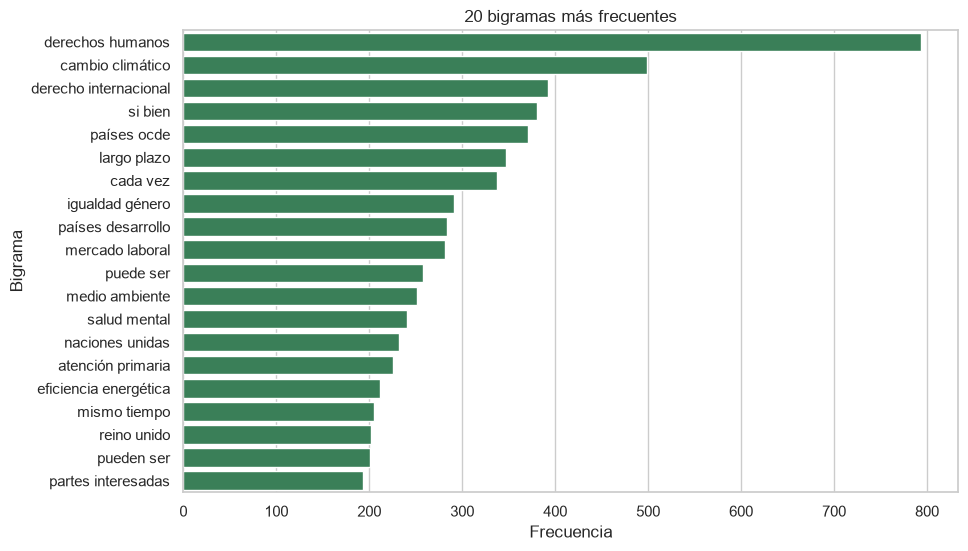

In [28]:
from sklearn.feature_extraction.text import CountVectorizer


def top_ngramas(textos, n, top=20, min_df=5):
    cv = CountVectorizer(
        stop_words=list(stopwords_es), ngram_range=(n, n), min_df=min_df
    )
    X = cv.fit_transform(textos)
    conteos = X.sum(axis=0).A1
    vocab = cv.get_feature_names_out()
    top_idx = conteos.argsort()[::-1][:top]
    return [(vocab[i], conteos[i]) for i in top_idx], len(vocab)


top_bigramas, n_bigramas = top_ngramas(data["textos"], n=2)
print("Bigramas distintos (min_df=5):", n_bigramas)

plt.figure(figsize=(10, 6))
palabras_b, frecuencias_b = zip(*top_bigramas)
sn.barplot(x=list(frecuencias_b), y=list(palabras_b), color="seagreen")
plt.title("20 bigramas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Bigrama")
plt.show()

Trigramas distintos (min_df=5): 1033


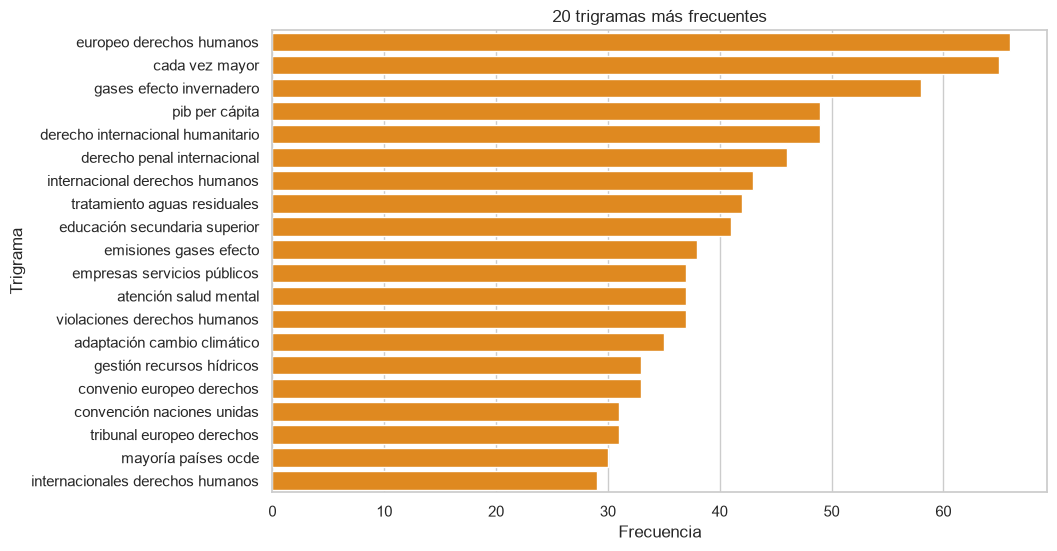

In [29]:
top_trigramas, n_trigramas = top_ngramas(data["textos"], n=3)
print("Trigramas distintos (min_df=5):", n_trigramas)

plt.figure(figsize=(10, 6))
palabras_t, frecuencias_t = zip(*top_trigramas)
sn.barplot(x=list(frecuencias_t), y=list(palabras_t), color="darkorange")
plt.title("20 trigramas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Trigrama")
plt.show()

**Observaciones sobre los n-gramas:**

- Los bigramas más frecuentes son conceptos claramente compuestos y temáticos: "derechos humanos" (794), "cambio climático" (499), "derecho internacional" (392), "igualdad género" (291), "mercado laboral", "salud mental", "eficiencia energética", "medio ambiente". Todos se relacionan directamente con ODS específicos (16, 13, 5, 8, 3, 7) y su significado se pierde si se separan en unigramas ("cambio" y "climático" por separado no aportan lo mismo que juntos).
- Los trigramas más frecuentes son en su mayoría extensiones de esos mismos bigramas ("gases efecto invernadero", "derecho penal internacional", "atención salud mental", "adaptación cambio climático") y ya aparecen con frecuencias bajas (<70 en el corpus completo) — son útiles pero mucho más dispersos, con 1033 trigramas distintos frente a 8539 bigramas (con `min_df=5`).

**Decisión para el pipeline de TF-IDF:** usar `ngram_range=(1, 2)` en el `TfidfVectorizer` para capturar estos bigramas informativos sin disparar demasiado la dimensionalidad de la matriz. No incluir trigramas: aportan poca señal adicional frente al costo en dimensionalidad y dispersión (relevante porque luego vamos a aplicar SVD truncado).

### Idioma / normalización

Los textos fueron traducidos al español con DeepL y aumentados con la API de ChatGPT, así que vale la pena revisar si quedaron residuos en otro idioma. No usamos un detector de idioma sofisticado (no está entre las dependencias del proyecto); en su lugar, aprovechamos la lista de stopwords en español ya cargada: en un texto realmente en español, una fracción considerable de las palabras deberían ser stopwords ("de", "la", "que"...). Un texto con muy pocas stopwords es candidato a estar en otro idioma o mezclado.

In [30]:
# Proporcion de stopwords en español por texto, como proxy de "que tan español" es el texto
def proporcion_stopwords(texto):
    tokens = tokenizar(texto)
    if not tokens:
        return 0.0
    return sum(1 for t in tokens if t in stopwords_es) / len(tokens)


data["prop_stopwords"] = data["textos"].apply(proporcion_stopwords)
data["prop_stopwords"].describe()

count    9656.000000
mean        0.475199
std         0.040730
min         0.156863
25%         0.452055
50%         0.477064
75%         0.500000
max         0.643836
Name: prop_stopwords, dtype: float64

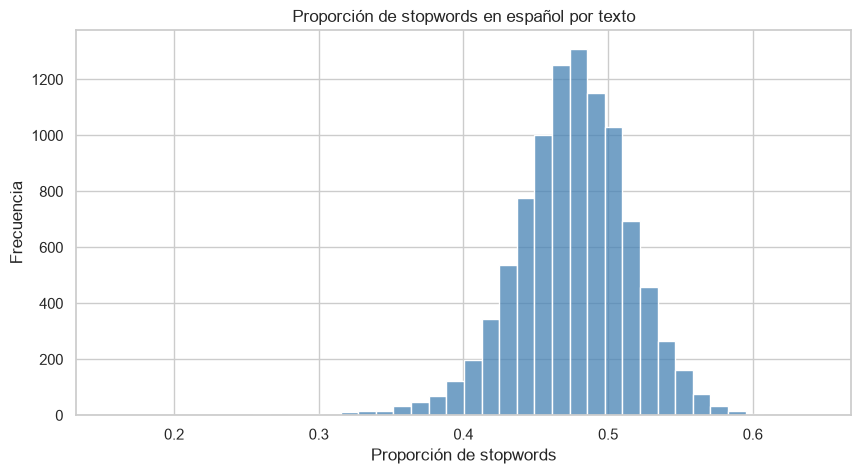

Textos con proporcion < 0.2: 6
Textos con proporcion < 0.25: 11
Textos con proporcion < 0.3: 26


In [31]:
# Histograma de la proporcion de stopwords, y conteo de textos sospechosos (poco español)
plt.figure(figsize=(10, 5))
sn.histplot(data["prop_stopwords"], bins=40, color="steelblue")
plt.title("Proporción de stopwords en español por texto")
plt.xlabel("Proporción de stopwords")
plt.ylabel("Frecuencia")
plt.show()

for umbral in (0.20, 0.25, 0.30):
    print(f"Textos con proporcion < {umbral}:", (data["prop_stopwords"] < umbral).sum())

In [32]:
# Inspeccion manual de los textos mas "sospechosos" (menor proporcion de stopwords en español)
sospechosos = data.sort_values("prop_stopwords").head(10)
for texto in sospechosos["textos"]:
    print("-", texto[:150])

- Definiciones Instrumentos de Planificacion Territorial IPT†(Definitions of Territorial Planning Instruments TPI), MINVU, Santiago, Chile, uiwui.minvu.
- The Challenge of Hunger: Focus on Financial Crisis and Gender Inequality, Instituto Internacional de Investigación sobre Políticas Alimentarias/Welthu
- Subvenciones al agua: Impact of higher irrigation rates on Central Valley Project farmers. United States General Accounting Office, GAO/RCED-94-8, Was
- Ginebra: Unión Internacional de Telecomunicaciones, 2015 (http://www. Cole-Lewis H, Kershaw T. Text messaging as a tool for behavior change in disease
- Tajik women in labour migration: forced tactics of survival or choice of emancipated women]. Globalizando el "postsocialismo": madres móviles y neolib
- Washington, DC, Banco Mundial: 60-66, disponible en: www.worldbank.org/html/fpd/esmap/energy_report2000/ch7.pdf. Viento de cola favorable, iniciación 
- Ambiente finlandés (2009), Towards a Recycling Society - the National Waste Plan

**Observaciones sobre idioma / normalización:**

- La proporción de stopwords en español se concentra fuertemente alrededor de 0.48 (media 0.475, desviación 0.04), con un rango típico entre 0.45 y 0.50 — consistente con texto en español bien formado.
- Hay una cola pequeña de textos con proporción baja: solo 6 con proporción < 0.20, 11 con < 0.25 y 26 con < 0.30 (de 9656, es decir <0.3% del corpus). Al inspeccionarlos manualmente, **no son errores de traducción**: son **referencias bibliográficas** con títulos de artículos/reportes originales sin traducir (en inglés, y algún caso en otros idiomas), mezclados con texto en español (nombres de instituciones, "disponible en", URLs).
- Dado lo marginal del fenómeno (<0.3% de los textos) y que el contenido en español sigue siendo mayoritario incluso en esos casos, **no se justifica un tratamiento especial** (ni excluir esos textos ni un detector de idioma dedicado). Se dejan tal cual; el `TfidfVectorizer` los tratará igual que al resto, y las palabras en inglés que aparezcan simplemente quedarán como tokens de baja frecuencia (poco peso) o serán descartadas por el `min_df` ya definido.

### Vocabulario distintivo por ODS

Las palabras más frecuentes por ODS suelen ser las mismas palabras genéricas del dominio ("países", "desarrollo", "políticas") que ya vimos en el vocabulario global, y no ayudan a diferenciar un ODS de otro. En su lugar calculamos un **ratio de distintividad**: para cada palabra dentro de un ODS, comparamos su frecuencia relativa en ese ODS contra su frecuencia relativa en todo el corpus. Un ratio alto indica una palabra mucho más común en ese ODS que en el resto. Exigimos al menos 15 apariciones dentro de la clase para evitar que palabras rarísimas (ruido) dominen el ranking solo por casualidad.

In [33]:
# Tokens de contenido por texto (reutilizando la tokenizacion y stopwords ya definidas)
data["tokens_filtrados"] = data["textos"].apply(
    lambda t: [w for w in tokenizar(t) if w not in stopwords_es and len(w) > 2]
)

contador_global = Counter()
for tokens in data["tokens_filtrados"]:
    contador_global.update(tokens)
total_global = sum(contador_global.values())


def palabras_distintivas(tokens_por_fila, min_conteo=15, top=8):
    contador_clase = Counter()
    for tokens in tokens_por_fila:
        contador_clase.update(tokens)
    total_clase = sum(contador_clase.values())

    ratios = []
    for palabra, conteo in contador_clase.items():
        if conteo < min_conteo:
            continue
        freq_clase = conteo / total_clase
        freq_global = contador_global[palabra] / total_global
        ratios.append((palabra, conteo, freq_clase / freq_global))

    ratios.sort(key=lambda x: -x[2])
    return [p for p, _, _ in ratios[:top]]


distintivas_por_ods = {
    ods: palabras_distintivas(grupo["tokens_filtrados"])
    for ods, grupo in data.groupby("ODS")
}

tabla_distintivas = pd.DataFrame(distintivas_por_ods).T
tabla_distintivas.columns = [f"top_{i + 1}" for i in range(tabla_distintivas.shape[1])]
tabla_distintivas.index.name = "ODS"
tabla_distintivas

,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8
ODS,,,,,,,,
1,ipm,indigencia,recuento,privación,multidimensional,privaciones,pobreza,extrema
2,cereales,arroz,trigo,leche,carne,variedades,maíz,inseguridad
3,cabecera,ambulatorios,cannabis,hospitalario,hospitalarias,copagos,clínica,bolsillo
4,pedagogías,pedagógicos,penang,docente,profesorado,pedagógica,vocacionales,pisa
5,empresarias,marido,sigi,discriminatorias,femeninos,estereotipos,cónyuges,masculinos
6,escorrentía,water,acuífero,dma,embalses,conagua,subterránea,subterráneas
7,fotovoltaica,mwh,twh,eólica,electrificación,turbinas,solar,eólicas
8,nacidos,despido,trabajador,desempleo,extranjero,juvenil,trabajadores,empleos
9,cti,blockchain,ancha,banda,móvil,software,digitales,internet


**Observaciones sobre el vocabulario distintivo por ODS:**

El resultado es muy alentador para el proyecto: cada ODS tiene un vocabulario distintivo claro y coherente con su temática oficial, por ejemplo:

- **ODS 1** (Fin de la pobreza): pobreza, indigencia, privación, multidimensional, extrema.
- **ODS 2** (Hambre cero): cereales, arroz, trigo, maíz, inseguridad (alimentaria).
- **ODS 4** (Educación de calidad): pedagógica, docente, profesorado, vocacionales, pisa (prueba PISA).
- **ODS 6** (Agua limpia): acuífero, escorrentía, embalses, aguas subterráneas.
- **ODS 7** (Energía asequible): fotovoltaica, eólica, turbinas, mwh/twh, solar.
- **ODS 9** (Industria e innovación): blockchain, banda ancha, internet, digitales.
- **ODS 12** (Producción responsable): plásticos, reciclaje, reciclado, vertederos.
- **ODS 14** (Vida submarina): pesquerías, atún, pescadores, sobrepesca.
- **ODS 15** (Vida de ecosistemas terrestres): bosque, biodiversidad, tala, forestal.

Esto confirma que el corpus tiene **señal semántica fuerte y bien separada por clase**, lo cual es una buena señal tanto para la construcción del TF-IDF (actividad 1) como para la interpretación cualitativa de los tópicos de LSA (actividad 2): si un componente del SVD trunca resalta palabras como "reciclaje/plásticos/vertederos", será razonable asociarlo al ODS 12.

### Conclusiones del EDA y decisiones para el pipeline

Resumen de lo encontrado en el análisis exploratorio y cómo se traduce en decisiones concretas para el pipeline de preparación de texto (actividad 1):

| Hallazgo | Decisión de pipeline |
|---|---|
| Sin nulos ni duplicados; 16 de 17 ODS presentes | No se requiere imputación ni deduplicación |
| Desbalance moderado entre clases (~3.5x entre la más y la menos frecuente) | `stratify=data["ODS"]` en el train/test split; evaluar con F1 macro y matriz de confusión, no solo accuracy |
| Longitud entre 24 y 268 palabras, ODS 16 sistemáticamente más largo | No se filtran textos por longitud; se deja que TF-IDF normalice por frecuencia |
| 42 textos con URLs, 1 con HTML | Limpieza con regex: remover URLs y etiquetas HTML antes de tokenizar |
| Top de vocabulario dominado por stopwords | Usar lista de stopwords en español (NLTK) en el `TfidfVectorizer` |
| Vocabulario grande (33,519 tokens únicos) | Fijar `min_df` (≈2-3) y `max_df` (≈0.9) para descartar ruido y términos casi universales |
| Bigramas informativos ("derechos humanos", "cambio climático"...); trigramas aportan poco | `ngram_range=(1, 2)` en el `TfidfVectorizer` |
| <0.3% de textos con residuos en otro idioma (referencias bibliográficas) | No se requiere tratamiento especial |
| Vocabulario claramente distintivo por ODS | Confirma que el enfoque TF-IDF + LSA es razonable: hay señal léxica suficiente para separar clases y para interpretar los tópicos del SVD frente a los ODS |

Con esto queda cerrado el análisis exploratorio del texto. El siguiente paso es construir el `Pipeline` de preparación (limpieza + `TfidfVectorizer`) de la actividad 1, aplicando las decisiones resumidas arriba.

## Actividad 1 — Preparación de los textos (BOW con TF-IDF)

Construimos un `Pipeline` de scikit-learn que integra las transformaciones decididas en el EDA: limpieza de URLs/HTML y luego vectorización TF-IDF con stopwords en español, bigramas y filtros de frecuencia.

Antes de vectorizar, separamos train/test: el vocabulario y los pesos IDF del `TfidfVectorizer` deben aprenderse **solo con datos de entrenamiento**, para no filtrar información del conjunto de prueba (data leakage) y así poder evaluar el modelo de clasificación de forma honesta en la actividad 3.

In [34]:
from sklearn.model_selection import train_test_split

# Split estratificado por ODS (justificado en el EDA por el desbalance de clases)
X_train, X_test, y_train, y_test = train_test_split(
    data["textos"],
    data["ODS"],
    test_size=0.2,
    random_state=42,
    stratify=data["ODS"],
)

print("Train:", X_train.shape[0], "textos")
print("Test: ", X_test.shape[0], "textos")

Train: 7724 textos
Test:  1932 textos


**Transformación de limpieza.** Un `TransformerMixin` propio que remueve URLs y etiquetas HTML (encontramos 42 y 1 respectivamente en el EDA) y normaliza espacios en blanco, para que quede integrado como un paso más del `Pipeline` (y así se pueda reutilizar igual en la app de Streamlit de la bonificación).

In [35]:
from sklearn.base import BaseEstimator, TransformerMixin


class LimpiezaTexto(BaseEstimator, TransformerMixin):
    """Quita URLs y etiquetas HTML, y normaliza espacios en blanco."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.apply(self._limpiar)

    @staticmethod
    def _limpiar(texto):
        texto = str(texto)
        texto = re.sub(r"http[s]?://\S+", " ", texto)
        texto = re.sub(r"<[^>]+>", " ", texto)
        texto = re.sub(r"\s+", " ", texto).strip()
        return texto

**Vectorización TF-IDF.** Parámetros elegidos y su justificación (todos derivados del EDA):

- `stop_words`: lista de stopwords en español de NLTK — dominaban el vocabulario bruto sin aportar señal.
- `ngram_range=(1, 2)`: unigramas + bigramas — los bigramas capturan conceptos como "derechos humanos" o "cambio climático" que un unigrama pierde.
- `min_df=3`: descarta términos que aparecen en menos de 3 textos (ruido/errores tipográficos).
- `max_df=0.9`: descarta términos presentes en más del 90% de los textos (no discriminan entre ODS).
- `token_pattern`: solo secuencias de letras (con tildes/ñ) de al menos 3 caracteres — evita tokens numéricos o de 1-2 letras poco informativos.
- `lowercase=True`: normaliza mayúsculas/minúsculas.

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline_tfidf = Pipeline(
    [
        ("limpieza", LimpiezaTexto()),
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words=list(stopwords_es),
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.9,
                token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
            ),
        ),
    ]
)

pipeline_tfidf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('limpieza', ...), ('tfidf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.","['sin', 'hasta', ...]"
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.","'(?u)\\b[^\\W\\d_]{3,}\\b'"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.9
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in 

In [37]:
# Ajustamos el pipeline SOLO con el train, y transformamos train y test con lo aprendido
X_train_tfidf = pipeline_tfidf.fit_transform(X_train)
X_test_tfidf = pipeline_tfidf.transform(X_test)

print("Matriz TF-IDF train:", X_train_tfidf.shape)
print("Matriz TF-IDF test: ", X_test_tfidf.shape)

Matriz TF-IDF train: (7724, 27851)
Matriz TF-IDF test:  (1932, 27851)


In [38]:
# Validacion rapida: tamaño de vocabulario resultante y dispersion de la matriz
vectorizador = pipeline_tfidf.named_steps["tfidf"]
vocabulario = vectorizador.get_feature_names_out()

print("Numero de terminos (features) del TF-IDF:", len(vocabulario))
print("Ejemplo de terminos:", list(vocabulario[:15]))

sparsity = 1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f"Sparsity de la matriz TF-IDF (train): {sparsity:.4%}")

Numero de terminos (features) del TF-IDF: 27851
Ejemplo de terminos: ['aarhus', 'abajo', 'abajo hacia', 'abandonadas', 'abandonado', 'abandonan', 'abandonan escuela', 'abandonar', 'abandonaron', 'abandonen', 'abandono', 'abandono escolar', 'abanico', 'abarca', 'abarcaban']
Sparsity de la matriz TF-IDF (train): 99.7911%


**Resultado:** el pipeline produce una matriz TF-IDF de ~27,800 términos (unigramas + bigramas) sobre los 7,724 textos de entrenamiento, con una dispersión (sparsity) cercana al 99.8% — esperable en BOW/TF-IDF, y justamente la razón por la que la actividad 2 aplica SVD truncado (LSA): reducir esta matriz dispersa y de alta dimensión a un espacio denso y manejable de tópicos.

Con el `Pipeline` ya ajustado sobre el train, quedamos listos para la actividad 2 (LSA con `TruncatedSVD`).

## Actividad 2 — Modelado de tópicos con LSA (TruncatedSVD)

Aplicamos `TruncatedSVD` sobre la matriz TF-IDF (`X_train_tfidf`) para obtener un análisis semántico latente (LSA). Primero exploramos cuánta varianza explica un rango de componentes entre 10 y 20 para elegir un número razonable, y luego interpretamos las palabras con mayor peso (loadings) de varios componentes como "tópicos".

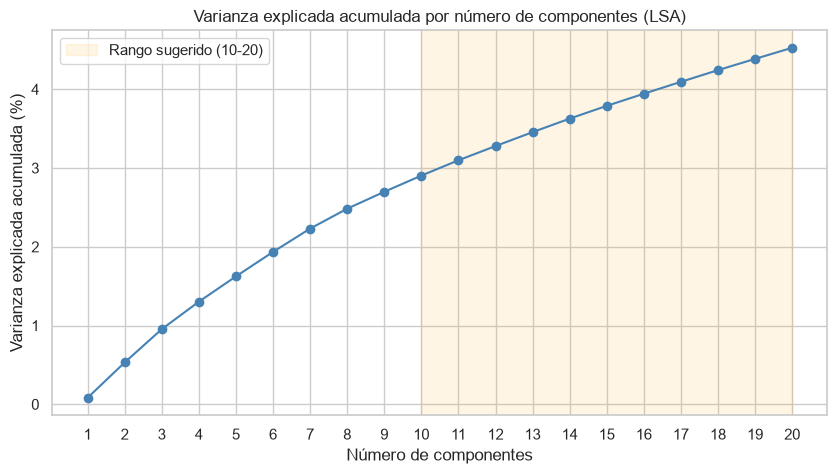

Varianza acumulada en 10, 15 y 20 componentes:
  n=10: 2.90%
  n=15: 3.79%
  n=20: 4.53%


In [39]:
from sklearn.decomposition import TruncatedSVD

# Exploramos la varianza explicada para un rango de componentes (10 a 20)
svd_explorador = TruncatedSVD(n_components=20, random_state=42)
svd_explorador.fit(X_train_tfidf)

varianza_acumulada = np.cumsum(svd_explorador.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), varianza_acumulada, marker="o", color="steelblue")
plt.axvspan(10, 20, color="orange", alpha=0.1, label="Rango sugerido (10-20)")
plt.title("Varianza explicada acumulada por número de componentes (LSA)")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada (%)")
plt.xticks(range(1, 21))
plt.legend()
plt.show()

print("Varianza acumulada en 10, 15 y 20 componentes:")
for n in (10, 15, 20):
    print(f"  n={n}: {varianza_acumulada[n - 1]:.2f}%")

**Elección del número de componentes.** La varianza explicada acumulada es baja en términos absolutos (~4.5% con 20 componentes) y crece de forma casi lineal, sin un "codo" marcado. Esto es esperable en TF-IDF con vocabulario grande (~27,800 términos) y un corpus con 16 temáticas distintas y balance parcial entre ellas: no hay una dirección dominante que concentre mucha varianza, como sí ocurriría en un corpus de un solo tema. Por eso el criterio de "varianza explicada" es menos útil aquí que de costumbre.

Elegimos **`n_components=15`**, en la mitad del rango sugerido (10-20), como compromiso entre:
- Suficientes componentes para poder interpretar varios tópicos distintos (pide la actividad al menos 5).
- No demasiados como para dificultar la interpretación cualitativa manual.
- Mantener la reducción de dimensionalidad (de ~27,800 a 15) que necesitaremos para el modelo de clasificación de la actividad 3, donde el desempeño predictivo (no la varianza explicada) es el criterio real de validación.

In [40]:
# Ajustamos el LSA final con 15 componentes, sobre el train
svd_lsa = TruncatedSVD(n_components=15, random_state=42)

X_train_lsa = svd_lsa.fit_transform(X_train_tfidf)
X_test_lsa = svd_lsa.transform(X_test_tfidf)

print("Dimension LSA train:", X_train_lsa.shape)
print("Dimension LSA test: ", X_test_lsa.shape)
print("Varianza explicada total (15 comp.):", f"{svd_lsa.explained_variance_ratio_.sum():.2%}")

Dimension LSA train: (7724, 15)
Dimension LSA test:  (1932, 15)
Varianza explicada total (15 comp.): 3.79%


In [41]:
# Palabras con mayor peso (loadings) por componente.
# Un componente de LSA suele ser un eje de contraste: tomamos las de mayor |peso|
# y mostramos su signo, ya que el signo indica en qué extremo del eje esta cada palabra.
vocabulario_tfidf = pipeline_tfidf.named_steps["tfidf"].get_feature_names_out()


def top_terminos_componente(componente, top=12):
    idx_ordenado = np.argsort(np.abs(componente))[::-1][:top]
    return [(vocabulario_tfidf[i], round(componente[i], 3)) for i in idx_ordenado]


for i, componente in enumerate(svd_lsa.components_):
    terminos = top_terminos_componente(componente)
    print(f"--- Componente {i + 1} ---")
    print(", ".join(f"{p} ({w:+.2f})" for p, w in terminos))
    print()

--- Componente 1 ---
mujeres (+0.16), países (+0.15), agua (+0.13), desarrollo (+0.12), género (+0.10), políticas (+0.10), pueden (+0.10), salud (+0.10), educación (+0.10), puede (+0.09), ocde (+0.09), pobreza (+0.09)

--- Componente 2 ---
derechos (+0.35), agua (-0.30), mujeres (+0.29), derecho (+0.28), derechos humanos (+0.26), humanos (+0.25), género (+0.17), internacional (+0.15), energía (-0.14), artículo (+0.12), derecho internacional (+0.11), hombres (+0.10)

--- Componente 3 ---
mujeres (+0.39), agua (-0.29), derechos (-0.23), derecho (-0.22), género (+0.20), derechos humanos (-0.19), humanos (-0.19), hombres (+0.17), internacional (-0.15), pobreza (+0.13), educación (+0.11), laboral (+0.10)

--- Componente 4 ---
agua (+0.43), mujeres (+0.39), salud (-0.28), atención (-0.23), género (+0.22), hombres (+0.15), mental (-0.14), educación (-0.14), salud mental (-0.14), estudiantes (-0.13), escuelas (-0.12), igualdad (+0.10)

--- Componente 5 ---
agua (+0.38), salud (+0.30), pobreza 

### Interpretación cualitativa de los tópicos

En LSA, el primer componente suele capturar la dirección de mayor varianza compartida por (casi) todos los documentos, y los siguientes suelen ser **ejes de contraste** entre dos o más temáticas (peso positivo en un extremo, negativo en el otro), no "tópicos" aislados y puros como en un modelo tipo LDA. Interpretamos al menos 5 componentes bajo esa lógica:

- **Componente 1** — mujeres, países, agua, desarrollo, género, políticas, salud, educación, pobreza (todos con peso positivo). No es un tópico específico: es el eje "genérico" del discurso de desarrollo, con vocabulario compartido por casi todos los ODS. Es normal que el primer componente de LSA se comporte así cuando el corpus mezcla muchas temáticas sin que una domine.

- **Componente 2** — positivo: *derechos, derecho, derechos humanos, humanos, internacional, artículo*; negativo: *agua, energía*. Eje de contraste entre vocabulario de **derechos humanos / marco legal** (ODS 16, y también ODS 5 y 10 en tanto tratan derechos e igualdad) frente a vocabulario de **agua y energía** (ODS 6 y 7). Relación clara con ODS específicos en ambos extremos.

- **Componente 4** — positivo: *agua, mujeres, género, hombres, igualdad*; negativo: *salud, atención, mental, educación, salud mental, estudiantes, escuelas*. Contrasta **agua + igualdad de género** (ODS 6 y 5) contra **salud y educación** (ODS 3 y 4). Muestra que el modelo separa estos cuatro ODS en un mismo eje, dos contra dos.

- **Componente 8** — positivo: *energía, electricidad, energética*; negativo: *climático, cambio climático, cambio, adaptación, pobreza, desarrollo*. Este es el más limpio: un eje casi puro entre **ODS 7 (energía asequible)** en el lado positivo y **ODS 13 (acción por el clima)** en el lado negativo — dos ODS que en la práctica suelen coaparecer en los mismos documentos (energía y clima), y aquí el LSA logra separarlos.

- **Componente 9** — positivo: *pobreza, género, igualdad, igualdad género, energía, políticas*; negativo: *climático, países, mujeres, cambio climático, cambio, ocde*. Vuelve a oponer **pobreza/igualdad de género** (ODS 1 y 5) contra **cambio climático** (ODS 13), reforzando lo visto en el componente 8: el cambio climático es una temática que el LSA aísla de forma consistente en varios componentes, casi siempre en el lado negativo.

**Conclusión general:** los tópicos de LSA sí guardan relación con los ODS, pero no de forma 1 a 1 —cada componente típicamente mezcla 2 a 4 ODS en un eje de contraste (positivo vs. negativo), coherente con que el vocabulario del dominio ODS comparte muchos términos transversales ("desarrollo", "políticas", "países"). Los ODS que aparecen de forma más nítida y repetida en los extremos de varios componentes son **13 (clima)**, **7 (energía)**, **5 (género)**, **6 (agua)**, **16 (derechos/justicia)** y **3/4 (salud/educación)** — que también fueron justamente los que mostraron vocabulario más distintivo en el EDA. Esto es evidencia consistente de que el pipeline TF-IDF + LSA captura señal semántica real y aprovechable para la clasificación de la actividad 3.

Con `X_train_lsa` y `X_test_lsa` (15 dimensiones densas, en vez de ~27,800 dispersas) quedamos listos para la actividad 3: entrenar un modelo de clasificación que relacione cada texto con su ODS, reutilizando esta misma descomposición LSA como reducción de dimensionalidad.

## Actividad 3 — Modelo de clasificación (búsqueda de hiperparámetros + validación cruzada)

Reutilizamos la descomposición LSA de la actividad 2 (`X_train_lsa`, 15 dimensiones densas) como espacio de entrada del clasificador. Entrenamos y comparamos dos algoritmos mediante `GridSearchCV`:

- **Regresión logística**: rápida, interpretable (coeficientes por ODS), buena base de comparación.
- **SVC (Support Vector Classifier)**: puede capturar fronteras no lineales entre ODS (kernel RBF), a mayor costo de cómputo.

Para ambos, el pipeline incluye un `StandardScaler` antes del clasificador (la salida de `TruncatedSVD` no está normalizada, y tanto la regularización de la regresión logística como el SVC son sensibles a la escala de las variables). La validación cruzada usa `StratifiedKFold` (mantiene la proporción de cada ODS en cada fold, dado el desbalance visto en el EDA) y `scoring="f1_macro"` (no accuracy, por la misma razón).

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Validacion cruzada estratificada, comun a ambas busquedas de hiperparametros
cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [43]:
# Regresion logistica: pipeline + grilla de hiperparametros
pipeline_lr = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=42)),
    ]
)

grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__class_weight": [None, "balanced"],
}

busqueda_lr = GridSearchCV(
    pipeline_lr, grid_lr, scoring="f1_macro", cv=cv_estratificado, n_jobs=-1
)
busqueda_lr.fit(X_train_lsa, y_train)

print("Mejor combinacion LR:", busqueda_lr.best_params_)
print(f"Mejor F1-macro (CV) LR: {busqueda_lr.best_score_:.4f}")

Mejor combinacion LR: {'clf__C': 10, 'clf__class_weight': None}
Mejor F1-macro (CV) LR: 0.7013


In [44]:
# SVC: pipeline + grilla de hiperparametros (separamos kernel lineal y rbf para no
# desperdiciar combinaciones de gamma, que no aplica al kernel lineal)
pipeline_svc = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", SVC(random_state=42)),
    ]
)

grid_svc = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__class_weight": [None, "balanced"],
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10, 100],
        "clf__gamma": ["scale", "auto", 0.01, 0.1],
        "clf__class_weight": [None, "balanced"],
    },
]

busqueda_svc = GridSearchCV(
    pipeline_svc, grid_svc, scoring="f1_macro", cv=cv_estratificado, n_jobs=-1
)
busqueda_svc.fit(X_train_lsa, y_train)

print("Mejor combinacion SVC:", busqueda_svc.best_params_)
print(f"Mejor F1-macro (CV) SVC: {busqueda_svc.best_score_:.4f}")

Mejor combinacion SVC: {'clf__C': 10, 'clf__class_weight': None, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}
Mejor F1-macro (CV) SVC: 0.7085


In [45]:
# Comparacion y seleccion del mejor modelo segun F1-macro de validacion cruzada
comparacion = pd.DataFrame(
    {
        "modelo": ["Regresion logistica", "SVC"],
        "mejor_f1_macro_cv": [busqueda_lr.best_score_, busqueda_svc.best_score_],
        "mejores_hiperparametros": [busqueda_lr.best_params_, busqueda_svc.best_params_],
    }
)
display(comparacion)

if busqueda_svc.best_score_ >= busqueda_lr.best_score_:
    modelo_final = busqueda_svc.best_estimator_
    nombre_modelo_final = "SVC"
else:
    modelo_final = busqueda_lr.best_estimator_
    nombre_modelo_final = "Regresion logistica"

print(f"Modelo seleccionado: {nombre_modelo_final}")

,modelo,mejor_f1_macro_cv,mejores_hiperparametros
0,Regresion logistica,0.701294,"{'clf__C': 10, 'clf__class_weight': None}"
1,SVC,0.708477,"{'clf__C': 10, 'clf__class_weight': None, 'clf..."


Modelo seleccionado: SVC


**Resultados y justificación de la selección:**

- **Regresión logística**: mejor configuración `C=10`, `class_weight=None`, F1-macro (CV) ≈ **0.70**.
- **SVC**: mejor configuración kernel `rbf`, `C=10`, `gamma=0.01`, `class_weight=None`, F1-macro (CV) ≈ **0.71**.

Los dos modelos quedan muy cerca (diferencia de ~1 punto porcentual en F1-macro), lo cual tiene sentido: ya redujimos el espacio a solo 15 dimensiones densas vía LSA, así que la frontera de decisión que necesita aprender el clasificador es relativamente simple y ambos algoritmos la capturan bien. El SVC con kernel RBF gana por un margen pequeño, probablemente porque puede modelar fronteras no lineales entre ODS que la regresión logística (lineal) no puede.

Seleccionamos el modelo con mejor F1-macro de validación cruzada (**SVC**) como modelo final para la actividad 4. Vale aclarar la contrapartida: la regresión logística entrena en una fracción del tiempo y es más interpretable (permite inspeccionar coeficientes por ODS); si en el futuro se requiere mayor velocidad o explicabilidad, es una alternativa razonable con una pérdida de desempeño mínima.

Ninguno de los dos modelos se entrenó ni se validó con el conjunto de test (`X_test_lsa`/`y_test`) — ese conjunto se reserva íntegro para la evaluación final de la actividad 4.

## Actividad 4 — Evaluación con textos no usados en el aprendizaje

Evaluamos `modelo_final` (SVC seleccionado en la actividad 3) sobre `X_test_lsa` / `y_test`: el 20% de los textos que se apartó desde el principio (actividad 1) y que nunca participó ni en el ajuste del `TfidfVectorizer`/`TruncatedSVD` ni en la validación cruzada del clasificador.

In [46]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

y_pred_test = modelo_final.predict(X_test_lsa)

print("Accuracy (test):", f"{accuracy_score(y_test, y_pred_test):.4f}")
print("F1-macro (test):", f"{f1_score(y_test, y_pred_test, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_test, digits=3))

Accuracy (test): 0.7821
F1-macro (test): 0.7091

              precision    recall  f1-score   support

           1      0.778     0.762     0.770       101
           2      0.553     0.635     0.591        74
           3      0.847     0.899     0.873       179
           4      0.920     0.956     0.938       205
           5      0.930     0.925     0.927       214
           6      0.892     0.892     0.892       139
           7      0.859     0.886     0.872       158
           8      0.560     0.472     0.512        89
           9      0.413     0.377     0.394        69
          10      0.661     0.586     0.621        70
          11      0.647     0.631     0.639       122
          12      0.604     0.516     0.557        62
          13      0.783     0.774     0.778        93
          14      0.541     0.440     0.485        75
          15      0.563     0.606     0.584        66
          16      0.876     0.949     0.911       216

    accuracy                   

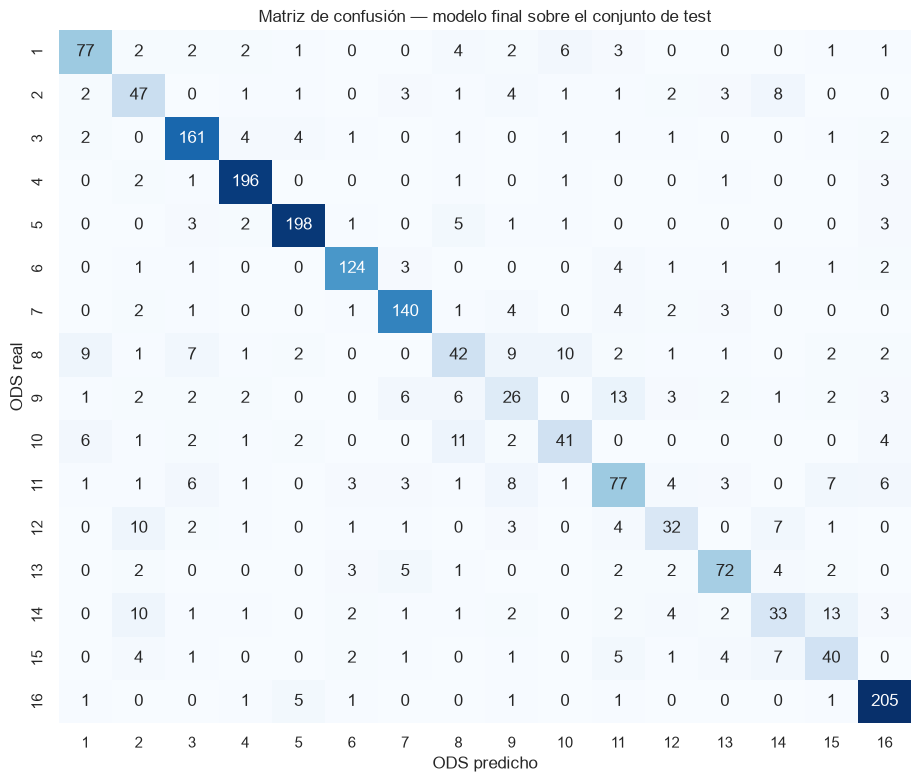

In [47]:
# Matriz de confusion, para ver entre que ODS se confunde el modelo
ods_ordenados = sorted(data["ODS"].unique())
matriz_confusion = confusion_matrix(y_test, y_pred_test, labels=ods_ordenados)

plt.figure(figsize=(11, 9))
sn.heatmap(
    matriz_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ods_ordenados,
    yticklabels=ods_ordenados,
    cbar=False,
)
plt.title("Matriz de confusión — modelo final sobre el conjunto de test")
plt.xlabel("ODS predicho")
plt.ylabel("ODS real")
plt.show()

**Interpretación de los resultados en test:**

- **Accuracy = 78.2%**, **F1-macro = 70.9%** — prácticamente igual al F1-macro de validación cruzada (≈0.71 en la actividad 3), lo que indica que el modelo **no está sobreajustado**: generaliza a textos nunca vistos igual de bien que a los folds de CV.
- Los ODS mejor clasificados son **4 (Educación, F1=0.94)**, **5 (Igualdad de género, F1=0.93)**, **16 (Paz/justicia, F1=0.91)**, **6 (Agua, F1=0.89)** y **7 (Energía, F1=0.87)** — coinciden exactamente con los ODS que ya habíamos visto con vocabulario más distintivo en el EDA y con ejes de contraste más limpios en el LSA (actividad 2).
- Los peor clasificados son **9 (Industria/innovación, F1=0.39)**, **14 (Vida submarina, F1=0.49)**, **8 (Trabajo decente, F1=0.51)** y **12 (Producción responsable, F1=0.56)** — son justamente algunos de los ODS con menos ejemplos en el dataset (312-377 textos, ver actividad EDA), lo que dificulta que el clasificador aprenda bien sus fronteras a pesar de usar `class_weight` en la búsqueda de hiperparámetros.
- La matriz de confusión muestra que los errores no son aleatorios sino que se concentran entre ODS temáticamente cercanos: **8 (Trabajo)** se confunde sobre todo con **10 (Desigualdad, 10 casos)** y **9 (Industria, 9 casos)**; **9 (Industria)** con **11 (Ciudades, 13 casos)**; y **14 (Vida submarina)** con **15 (Vida terrestre, 13 casos)** y **2 (Hambre cero, 10 casos)** — pares de ODS que comparten vocabulario económico o ambiental y que incluso a un experto humano podrían costarle distinguir con un fragmento corto de texto.

### Clasificación de textos individuales del conjunto de test

Mostramos el ODS real y el predicho por `modelo_final` para una muestra de textos del test (nunca vistos durante el entrenamiento), incluyendo tanto aciertos como errores para una evaluación honesta del desempeño.

In [48]:
resultados_test = pd.DataFrame(
    {
        "texto": X_test.values,
        "ods_real": y_test.values,
        "ods_predicho": y_pred_test,
    }
)
resultados_test["correcto"] = resultados_test["ods_real"] == resultados_test["ods_predicho"]
resultados_test["texto_resumen"] = resultados_test["texto"].str.slice(0, 140) + "..."

muestra_test = resultados_test.sample(n=6, random_state=7)
muestra_test[["texto_resumen", "ods_real", "ods_predicho", "correcto"]]

,texto_resumen,ods_real,ods_predicho,correcto
1662,Esta es la razón por la que las redes de calef...,7,7,True
885,Si bien la infraestructura tiene efectos susta...,9,1,False
1517,"Sin embargo, no toda formulación de políticas ...",3,3,True
1784,"Por primera vez, PISA 2012 también incluyó una...",4,4,True
1125,"Las medidas monetarias pueden ser precisas ""en...",1,1,True
829,"Además, un aumento del 1% de la parte de la ag...",11,7,False


En esta muestra de 6 textos de test, 4 quedaron bien clasificados (ODS 7-Energía, 3-Salud, 4-Educación y 1-Pobreza) y 2 mal clasificados (un texto de ODS 9-Industria predicho como 1-Pobreza, y uno de ODS 11-Ciudades predicho como 7-Energía). Este es justo el tipo de error esperado según la matriz de confusión: ODS con menos ejemplos de entrenamiento y vocabulario más solapado con otros temas económicos/urbanos.

### Cierre

El pipeline completo (limpieza → TF-IDF → LSA → SVC) queda entrenado y evaluado de punta a punta: EDA con decisiones justificadas, `Pipeline` de preparación de texto, modelo de tópicos LSA interpretado cualitativamente frente a los ODS, y un clasificador con búsqueda de hiperparámetros y validación cruzada, evaluado honestamente sobre texto nunca visto (F1-macro test ≈ 0.71, consistente con CV). Como paso opcional (bonificación), este mismo `pipeline_tfidf` + `svd_lsa` + `modelo_final` se podría envolver en una app de Streamlit que reciba texto libre y devuelva la predicción del ODS.

## Modelado adicional — búsqueda del mejor rendimiento

Esta sección es exploratoria, por fuera de lo mínimo pedido por la rúbrica, y no reemplaza el `modelo_final` de las actividades 3 y 4 (que se queda como la entrega principal).

**Hipótesis:** en la actividad 2 usamos `n_components=15` para el LSA porque ese tamaño es el que se puede interpretar cualitativamente a mano (rúbrica: "explora entre 10 y 20 componentes"). Pero para el *clasificador* no hay ninguna razón para quedarnos con esas mismas 15 dimensiones — el enunciado permite explícitamente "reutilizar la misma descomposición SVD... o aplicar otro algoritmo de reducción que se considere pertinente". Con solo 15 componentes capturábamos ~3.8% de la varianza de la matriz TF-IDF; es esperable que un LSA más grande retenga más señal útil para separar los ODS.

Probamos un LSA con más componentes y ajustamos **3 modelos** (evitando modelos de árboles/ensambles): **regresión logística**, **SVC** y una **red neuronal pequeña (`MLPClassifier`)**, cada uno con su propia búsqueda de hiperparámetros por validación cruzada.

In [49]:
# LSA con mas componentes, separado del de la actividad 2 (que se uso para interpretar topicos).
# Aqui el objetivo es maximizar el rendimiento del clasificador, no la interpretabilidad.
svd_mejor = TruncatedSVD(n_components=150, random_state=42)

X_train_lsa2 = svd_mejor.fit_transform(X_train_tfidf)
X_test_lsa2 = svd_mejor.transform(X_test_tfidf)

print("Dimension LSA (150 comp.) train:", X_train_lsa2.shape)
print("Dimension LSA (150 comp.) test: ", X_test_lsa2.shape)
print("Varianza explicada total:", f"{svd_mejor.explained_variance_ratio_.sum():.2%}")

Dimension LSA (150 comp.) train: (7724, 150)
Dimension LSA (150 comp.) test:  (1932, 150)
Varianza explicada total: 15.51%


Con 150 componentes la varianza explicada sube a ~15.5% (vs. ~3.8% con 15 componentes en la actividad 2) — mucha más información conservada, mientras seguimos reduciendo el espacio original de ~27,800 términos en un factor de ~185x.

In [50]:
# Regresion logistica, sobre el nuevo espacio LSA de 150 componentes
pipeline_lr2 = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, random_state=42)),
    ]
)
grid_lr2 = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__class_weight": [None, "balanced"],
}
busqueda_lr2 = GridSearchCV(
    pipeline_lr2, grid_lr2, scoring="f1_macro", cv=cv_estratificado, n_jobs=-1
)
busqueda_lr2.fit(X_train_lsa2, y_train)

print("Mejor combinacion LR:", busqueda_lr2.best_params_)
print(f"Mejor F1-macro (CV) LR: {busqueda_lr2.best_score_:.4f}")

Mejor combinacion LR: {'clf__C': 0.01, 'clf__class_weight': None}
Mejor F1-macro (CV) LR: 0.8334


In [51]:
# SVC, sobre el nuevo espacio LSA de 150 componentes
pipeline_svc2 = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", SVC(random_state=42)),
    ]
)
grid_svc2 = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__class_weight": [None, "balanced"],
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10, 100],
        "clf__gamma": ["scale", "auto", 0.01, 0.1],
        "clf__class_weight": [None, "balanced"],
    },
]
busqueda_svc2 = GridSearchCV(
    pipeline_svc2, grid_svc2, scoring="f1_macro", cv=cv_estratificado, n_jobs=-1
)
busqueda_svc2.fit(X_train_lsa2, y_train)

print("Mejor combinacion SVC:", busqueda_svc2.best_params_)
print(f"Mejor F1-macro (CV) SVC: {busqueda_svc2.best_score_:.4f}")

Mejor combinacion SVC: {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejor F1-macro (CV) SVC: 0.8304


In [52]:
# Red neuronal pequena (MLPClassifier), sobre el nuevo espacio LSA de 150 componentes
from sklearn.neural_network import MLPClassifier

pipeline_mlp = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
        ),
    ]
)
grid_mlp = {
    "clf__hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "clf__alpha": [0.0001, 0.001, 0.01],
}
busqueda_mlp = GridSearchCV(
    pipeline_mlp, grid_mlp, scoring="f1_macro", cv=cv_estratificado, n_jobs=-1
)
busqueda_mlp.fit(X_train_lsa2, y_train)

print("Mejor combinacion MLP:", busqueda_mlp.best_params_)
print(f"Mejor F1-macro (CV) MLP: {busqueda_mlp.best_score_:.4f}")

Mejor combinacion MLP: {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (100,)}
Mejor F1-macro (CV) MLP: 0.8150


In [53]:
# Comparacion de los 3 modelos y seleccion del mejor segun F1-macro de CV
comparacion2 = pd.DataFrame(
    {
        "modelo": ["Regresion logistica", "SVC", "MLP (red neuronal)"],
        "mejor_f1_macro_cv": [
            busqueda_lr2.best_score_,
            busqueda_svc2.best_score_,
            busqueda_mlp.best_score_,
        ],
        "mejores_hiperparametros": [
            busqueda_lr2.best_params_,
            busqueda_svc2.best_params_,
            busqueda_mlp.best_params_,
        ],
    }
)
display(comparacion2)

busquedas = {
    "Regresion logistica": busqueda_lr2,
    "SVC": busqueda_svc2,
    "MLP (red neuronal)": busqueda_mlp,
}
nombre_mejor_v2 = max(busquedas, key=lambda k: busquedas[k].best_score_)
modelo_final_v2 = busquedas[nombre_mejor_v2].best_estimator_

print(f"Modelo seleccionado: {nombre_mejor_v2}")

,modelo,mejor_f1_macro_cv,mejores_hiperparametros
0,Regresion logistica,0.833370,"{'clf__C': 0.01, 'clf__class_weight': None}"
1,SVC,0.830412,"{'clf__C': 1, 'clf__class_weight': 'balanced',..."
2,MLP (red neuronal),0.815006,"{'clf__alpha': 0.0001, 'clf__hidden_layer_size..."


Modelo seleccionado: Regresion logistica


In [54]:
# Evaluacion del mejor modelo (v2) sobre el conjunto de test
y_pred_test2 = modelo_final_v2.predict(X_test_lsa2)

print("Accuracy (test):", f"{accuracy_score(y_test, y_pred_test2):.4f}")
print("F1-macro (test):", f"{f1_score(y_test, y_pred_test2, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_test2, digits=3))

Accuracy (test): 0.8659
F1-macro (test): 0.8357

              precision    recall  f1-score   support

           1      0.842     0.792     0.816       101
           2      0.782     0.824     0.803        74
           3      0.857     0.939     0.896       179
           4      0.925     0.966     0.945       205
           5      0.938     0.925     0.932       214
           6      0.940     0.906     0.923       139
           7      0.896     0.930     0.913       158
           8      0.568     0.562     0.565        89
           9      0.765     0.754     0.759        69
          10      0.754     0.614     0.677        70
          11      0.774     0.787     0.780       122
          12      0.800     0.774     0.787        62
          13      0.862     0.871     0.866        93
          14      0.914     0.853     0.883        75
          15      0.932     0.833     0.880        66
          16      0.936     0.954     0.945       216

    accuracy                   

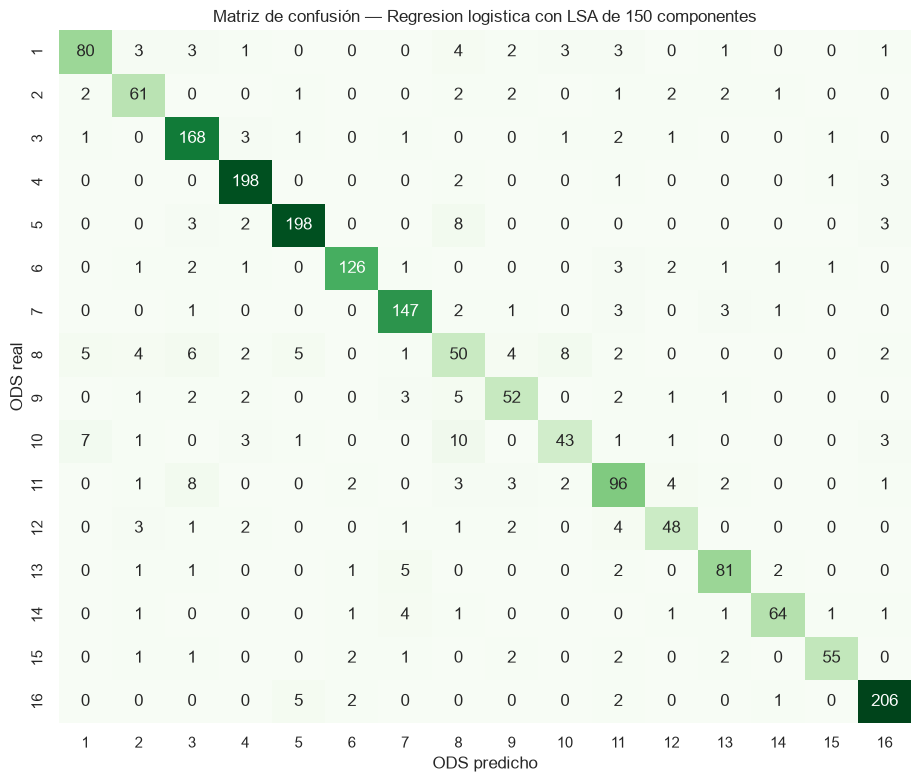

: 

In [ ]:
matriz_confusion2 = confusion_matrix(y_test, y_pred_test2, labels=ods_ordenados)

plt.figure(figsize=(11, 9))
sn.heatmap(
    matriz_confusion2,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=ods_ordenados,
    yticklabels=ods_ordenados,
    cbar=False,
)
plt.title(f"Matriz de confusión — {nombre_mejor_v2} con LSA de 150 componentes")
plt.xlabel("ODS predicho")
plt.ylabel("ODS real")
plt.show()

**Resultado:**

| Modelo | Mejores hiperparámetros | F1-macro (CV) |
|---|---|---|
| Regresión logística | `C=0.01`, `class_weight=None` | 0.833 |
| SVC | `kernel=rbf`, `C=1`, `gamma=scale`, `class_weight=balanced` | 0.830 |
| MLP (red neuronal) | `hidden_layer_sizes=(100,)`, `alpha=0.0001` | 0.815 |

Gana la **regresión logística**, y en el conjunto de test: **accuracy = 86.6%**, **F1-macro = 83.6%** — una mejora sustancial frente al modelo de las actividades 3-4 (LSA de 15 componentes, SVC, F1-macro test = 70.9%): **+12.7 puntos de F1-macro**.

**¿Por qué funciona tanto mejor?** Confirma la hipótesis inicial: 15 componentes eran insuficientes para retener la señal semántica necesaria para clasificar bien 16 clases — estábamos comprimiendo demasiado la información antes de que llegara al clasificador. Con 150 componentes el modelo tiene mucho más margen para separar las clases, y sigue siendo una reducción enorme frente a las ~27,800 columnas del TF-IDF original (computacionalmente manejable: la búsqueda de hiperparámetros de los 3 modelos completa tomó menos de dos minutos).

Es interesante que aquí gane la regresión logística (el modelo más simple de los tres) y no el SVC o la red neuronal — con más dimensiones, un clasificador lineal ya tiene suficiente expresividad para separar las clases, y los modelos más complejos no aportan ventaja adicional (y sí más tiempo de cómputo, sobre todo el SVC).

**Nota:** esta sección es una exploración adicional; el entregable formal de las actividades 3 y 4 sigue siendo `modelo_final` (SVC sobre LSA de 15 componentes), que es coherente con la descomposición interpretada cualitativamente en la actividad 2.